<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/Tokenizer_FFNN_Storms.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 5 — The Keras Tokenizer: TF-IDF of the top 10,000 words
- Hands-off this time: ALL the storm types, and let Keras do the cleaning.
- 61,324 rows -> shuffle -> dropna keeps complete cases: 28,966.
- 15 classes, badly imbalanced: Thunderstorm Wind 13,178 ... Marine Hail 12, Dust Devil 6. Remember Dust Devil.
- LabelEncoder + one-hot: one column per class, ALPHABETICAL (Debris Flow = 0, Dust Devil = 1, Flash Flood = 2 ...).
- Split the TEXT first (70/30: 20,276 / 8,690), then fit the Tokenizer on the training narratives only - same rule as video 3.
- ONE tool, TWO steps (like sklearn fit/transform): Step 1 fit_on_texts(train) LEARNS the vocabulary - word_index ranks words ('the' = 1), word_counts = times, word_docs = narratives (the DF behind IDF). Step 2 texts_to_matrix(mode='tfidf') CONVERTS train and test into 10,000 columns. It lowercases and strips punctuation but does NOT drop stop words. (texts_to_sequences keeps word order - that's M5.2.)
- Why PCA/t-SNE: before a million-parameter network, PEEK - do the storm types live in different places? 10,000 columns squashed to 2, one dot per narrative (hail vs flash flood). PCA (first components 3.7%, 1.7%, 1.1% of the variance) already shows hail as a tight clump; t-SNE shows two clean islands. Payoff: that's why the EDA models hit 0.99. (2022's confetti plot was a bug - only 688 of 6,606 dots, colors lined up by index label.)
-->

# Tokenizer and FFNNs (feature engineering a sequence!)
**Dr. Dave Wanik - University of Connecticut**

Keras isn't a full-blown NLP library (you'll want to use Spacy or NLTK for that). But it does have quite a bit that makes it easy to get up and running with text sequence data (for now, we ignore the sequence and create features for modeling like count of words in each document (sample) or the TF_IDF (which penalizes for length of document in addition to frequency).

![alt text](https://pbs.twimg.com/media/D7l5pgDXsAAMX98.jpg)

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow import keras
import pandas as pd
import json
import numpy as np

In [2]:
# seed everything: same numbers on my screen and yours
# (and we re-seed right before every model build, so model 2 is as reproducible as model 1)
import keras
import tensorflow as tf

keras.utils.set_random_seed(5509)
tf.config.experimental.enable_op_determinism()

## Read the data

In [3]:
# we will read the file directly from this link
# url = "https://drive.google.com/uc?export=download&id=1jvIwUFVMZE7bQwGQeiu1yT6CSIdieu6_"

# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module5_Files/data/StormEvents_2019.csv"

df = pd.read_csv(url, header = 0) # this means there is a header in the first row
df = pd.DataFrame(df)
df.head()

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,137295,824116,TEXAS,48,2019,May,Flash Flood,BEXAR,5/9/2019 15:54,CST-6,...,N,LEON SPGS,NNE,SAN GERONIMO,29.7898,-98.6406,29.7158,-98.7744,Thunderstorms developed along a cold front as ...,Thunderstorms produced heavy rain that led to ...
1,140217,843354,MINNESOTA,27,2019,July,Thunderstorm Wind,PINE,7/15/2019 16:40,CST-6,...,E,ROCK CREEK,E,ROCK CREEK,45.7700,-92.8700,45.7700,-92.8700,An area of low pressure over southern Manitoba...,A 14-inch tree fell due to the winds and damag...
2,142648,861581,TEXAS,48,2019,October,Thunderstorm Wind,VAN ZANDT,10/20/2019 22:23,CST-6,...,N,EDGEWOOD,N,EDGEWOOD,32.7100,-95.8800,32.7100,-95.8800,Thunderstorms erupted across the DFW Metroplex...,A trained spotter measured a wind gust of 67 M...
3,142648,861584,TEXAS,48,2019,October,Thunderstorm Wind,TARRANT,10/20/2019 23:12,CST-6,...,WSW,AZLE,WSW,AZLE,32.8700,-97.6100,32.8700,-97.6100,Thunderstorms erupted across the DFW Metroplex...,The local police department reported a wind gu...
4,142648,861582,TEXAS,48,2019,October,Thunderstorm Wind,PALO PINTO,10/20/2019 22:36,CST-6,...,N,MINERAL WELLS,N,MINERAL WELLS,32.8000,-98.1000,32.8000,-98.1000,Thunderstorms erupted across the DFW Metroplex...,A wind gust of 75 MPH was measured by the Auto...


In [4]:
# shuffle the data inplace
df = df.sample(frac=1).reset_index(drop=True)
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 61324 entries, 0 to 61323
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EPISODE_ID         61324 non-null  int64  
 1   EVENT_ID           61324 non-null  int64  
 2   STATE              61324 non-null  str    
 3   STATE_FIPS         61324 non-null  int64  
 4   YEAR               61324 non-null  int64  
 5   MONTH_NAME         61324 non-null  str    
 6   EVENT_TYPE         61324 non-null  str    
 7   CZ_NAME            61324 non-null  str    
 8   BEGIN_DATE_TIME    61324 non-null  str    
 9   CZ_TIMEZONE        61324 non-null  str    
 10  END_DATE_TIME      61324 non-null  str    
 11  INJURIES_DIRECT    61324 non-null  int64  
 12  INJURIES_INDIRECT  61324 non-null  int64  
 13  DEATHS_DIRECT      61324 non-null  int64  
 14  DEATHS_INDIRECT    61324 non-null  int64  
 15  DAMAGE_PROPERTY    49501 non-null  str    
 16  DAMAGE_CROPS       49928 non-null

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,133625,799434,HAWAII,15,2019,February,High Surf,BIG ISLAND NORTH AND EAST,2/6/2019 7:00,HST-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A northeast swell produced surf of 6 to 10 fee...,NaN
1,137129,822870,TENNESSEE,47,2019,June,Thunderstorm Wind,SEVIER,6/20/2019 17:00,EST-5,...,SSW,BEECH SPGS,SSW,BEECH SPGS,35.95,-83.61,35.95,-83.61,A cool front pushed southeast into the Souther...,One tree was down along Douglas Dam Road in Ko...
2,140556,844827,COLORADO,8,2019,September,Hail,BOULDER,9/11/2019 15:37,MST-7,...,NW,LONGMONT,NW,LONGMONT,40.19,-105.12,40.19,-105.12,"Severe thunderstorms produced two tornadoes, a...",NaN
3,132434,792366,MINNESOTA,27,2019,January,Extreme Cold/Wind Chill,PENNINGTON,1/1/2019 0:00,CST-6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Frigid surface high pressure built into the ar...,NaN
4,137622,830560,PENNSYLVANIA,42,2019,July,Thunderstorm Wind,FAYETTE,7/2/2019 19:48,EST-5,...,E,BROWNSVILLE,E,BROWNSVILLE,40.02,-79.89,40.02,-79.89,A warm frontal boundary moved into eastern Ohi...,Report of large trees snapped and uprooted in ...


In [5]:
# return complete cases
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 28966 entries, 4 to 61323
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EPISODE_ID         28966 non-null  int64  
 1   EVENT_ID           28966 non-null  int64  
 2   STATE              28966 non-null  str    
 3   STATE_FIPS         28966 non-null  int64  
 4   YEAR               28966 non-null  int64  
 5   MONTH_NAME         28966 non-null  str    
 6   EVENT_TYPE         28966 non-null  str    
 7   CZ_NAME            28966 non-null  str    
 8   BEGIN_DATE_TIME    28966 non-null  str    
 9   CZ_TIMEZONE        28966 non-null  str    
 10  END_DATE_TIME      28966 non-null  str    
 11  INJURIES_DIRECT    28966 non-null  int64  
 12  INJURIES_INDIRECT  28966 non-null  int64  
 13  DEATHS_DIRECT      28966 non-null  int64  
 14  DEATHS_INDIRECT    28966 non-null  int64  
 15  DAMAGE_PROPERTY    28966 non-null  str    
 16  DAMAGE_CROPS       28966 non-null  str

# Splitting Data

In [6]:
df.head()

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
4,137622,830560,PENNSYLVANIA,42,2019,July,Thunderstorm Wind,FAYETTE,7/2/2019 19:48,EST-5,...,E,BROWNSVILLE,E,BROWNSVILLE,40.02,-79.89,40.02,-79.89,A warm frontal boundary moved into eastern Ohi...,Report of large trees snapped and uprooted in ...
7,137621,830530,OHIO,39,2019,July,Thunderstorm Wind,BELMONT,7/2/2019 18:38,EST-5,...,NW,COLERAIN,NW,COLERAIN,40.13,-80.81,40.13,-80.81,A warm frontal boundary moved into eastern Ohi...,A local 911 call center reported power lines d...
11,140719,845926,OHIO,39,2019,July,Thunderstorm Wind,PUTNAM,7/10/2019 18:28,EST-5,...,E,CLOVERDALE,E,CLOVERDALE,41.02,-84.27,41.02,-84.27,Pre frontal trough and remnant outflow boundar...,The public reported significant damage to the ...
15,141169,852190,PENNSYLVANIA,42,2019,August,Thunderstorm Wind,ALLEGHENY,8/17/2019 18:16,EST-5,...,SE,MONTROSE HILL,SE,MONTROSE HILL,40.51,-79.84,40.51,-79.84,"A weak, low-amplitude shortwave crossed the re...",The county emergency manager reported that sev...
16,140167,851570,PENNSYLVANIA,42,2019,August,Thunderstorm Wind,SUSQUEHANNA,8/15/2019 20:42,EST-5,...,W,BIRCHARDVILLE,W,BIRCHARDVILLE,41.85,-76.06,41.85,-76.06,A surface trough along with an upper level wav...,Strong thunderstorm winds brought down multipl...


In [7]:
# since we have shuffled, we can specify X and Y then split
X = df['EVENT_NARRATIVE']
y = df['EVENT_TYPE']
print(X.shape, y.shape)

(28966,) (28966,)


In [8]:
y.nunique()

15

In [9]:
y.value_counts()

EVENT_TYPE
Thunderstorm Wind           13178
Flood                        4253
Flash Flood                  3851
Hail                         2755
Marine Thunderstorm Wind     1537
Tornado                      1329
Heavy Rain                   1101
Lightning                     300
Funnel Cloud                  268
Debris Flow                   168
Waterspout                    145
Marine High Wind               47
Marine Strong Wind             16
Marine Hail                    12
Dust Devil                      6
Name: count, dtype: int64

# LabelEncoder() for Y

In [10]:
lb = LabelEncoder()
y = lb.fit_transform(y)
y = keras.utils.to_categorical(y)
y

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(28966, 15))

In [11]:
lb_name_mapping = dict(zip(lb.classes_, lb.transform(lb.classes_)))
print(lb_name_mapping)

{'Debris Flow': np.int64(0), 'Dust Devil': np.int64(1), 'Flash Flood': np.int64(2), 'Flood': np.int64(3), 'Funnel Cloud': np.int64(4), 'Hail': np.int64(5), 'Heavy Rain': np.int64(6), 'Lightning': np.int64(7), 'Marine Hail': np.int64(8), 'Marine High Wind': np.int64(9), 'Marine Strong Wind': np.int64(10), 'Marine Thunderstorm Wind': np.int64(11), 'Thunderstorm Wind': np.int64(12), 'Tornado': np.int64(13), 'Waterspout': np.int64(14)}


In [12]:
y[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

# Train and Test Partition - split FIRST
The Tokenizer learns a vocabulary and TF-IDF weights, so it only gets to see the **training** narratives.

In [13]:
# split the TEXT first, then fit the Tokenizer on the training text only
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y,
                                                              random_state=42,
                                                              train_size=0.7)
print(X_train_text.shape, y_train.shape)
print(X_test_text.shape, y_test.shape)

(20276,) (20276, 15)
(8690,) (8690, 15)


# Tokenizer() - one tool, two steps
The Keras `Tokenizer` works just like scikit-learn's `fit` and `transform`:
1. **Learn** - `fit_on_texts()` reads the TRAINING narratives and learns the vocabulary: every word's rank, how many times it appears, and how many narratives it appears in.
2. **Convert** - `texts_to_matrix()` uses what it learned to turn any narrative into a row of 10,000 numbers.

You always need both: learn once (on train), then convert train AND test with the same Tokenizer.

### Step 1: learn the vocabulary

In [14]:
# Step 1 - LEARN: the Keras Tokenizer reads the training narratives (like sklearn's fit)
# check documentation for Tokenizer - it's awesome! https://keras.io/api/preprocessing/text/
from tensorflow.keras.preprocessing.text import Tokenizer  # Keras 3 dropped keras.preprocessing.text; this path still works in Colab
t = Tokenizer(num_words=10000) # play with this! 100, 1000, 10000... keep only the most common words
t.fit_on_texts(X_train_text)   # TRAIN only

# what did it learn?
print('narratives read:', t.document_count)
print('unique words found:', len(t.word_index), '- num_words=10000 keeps the 10,000 most common')

# word_index ranks every word by how common it is - 'the' is word number 1
first_ten = {}
for word in list(t.word_index)[0:10]:
    first_ten[word] = t.word_index[word]
print(first_ten)
print()

# word_counts = how many TIMES a word appears; word_docs = how many NARRATIVES it appears in
# (word_docs is the DF in TF-IDF: a word in lots of narratives gets a small IDF)
for word in ['the', 'hail', 'tornado', 'waterspout']:
    print(f'{word:12s} appears {t.word_counts[word]:6d} times, in {t.word_docs[word]:6d} narratives')

narratives read: 20276
unique words found: 16050 - num_words=10000 keeps the 10,000 most common
{'the': 1, 'of': 2, 'a': 3, 'and': 4, 'was': 5, 'in': 6, 'to': 7, 'at': 8, 'were': 9, 'on': 10}

the          appears  21997 times, in   9101 narratives
hail         appears   1944 times, in   1826 narratives
tornado      appears   2420 times, in    917 narratives
waterspout   appears    112 times, in     98 narratives


### Step 2: turn text into numbers - `texts_to_matrix()`
Each narrative becomes one row with a column for each of the 10,000 words. Pick what goes in the cells with `mode`:

* `'binary'` - 1 if the word is in the narrative, 0 if not (the default)
* `'count'` - how many times the word appears
* `'freq'` - the count divided by the narrative's length
* `'tfidf'` - TF-IDF, same idea as EDA_ML_Storms: common-everywhere words get turned down **(what we use)**

Read Brownlee for more details: https://machinelearningmastery.com/prepare-text-data-deep-learning-keras/

Try playing with 100 vs. 1000 vs. 10000 `num_words` (in the `Tokenizer()`) and see how your results may or may not change... just because you have all the data doesn't mean you have to use it.

**NOTE:** word order is thrown away here - we are creating features for modeling, a bag of words. (Keeping the order is `texts_to_sequences()`, which turns each word into its word_index number - that's M5.2.) Instead of a FFNN, you could use a random forest below (but warning, it probs will take a long time to fit).

In [15]:
# Step 2 - CONVERT: same Tokenizer for both, learned on train (like sklearn's transform)
X_train = t.texts_to_matrix(X_train_text, mode='tfidf') # try 'binary', 'count' or 'freq' instead!
X_test = t.texts_to_matrix(X_test_text, mode='tfidf')
print(X_train)
print(X_train.shape, X_test.shape) # one row per narrative, one column per word

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         1.17175193 0.         ... 0.         0.         0.        ]
 [0.         0.         1.13529238 ... 0.         0.         0.        ]
 ...
 [0.         1.98394847 1.9222171  ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         3.74635405 3.7493997  ... 0.         0.         0.        ]]
(20276, 10000) (8690, 10000)


# Visualization with PCA and t-SNE
**Why bother?** Before we spend a million parameters on a neural network, take a peek: do the storm types even live in different places? Each narrative is a row of 10,000 TF-IDF numbers - far too many to plot. PCA and t-SNE squash those 10,000 columns down to **2**, so we can draw one dot per narrative and color it by storm type. **If the colors separate, a model can find the boundary.** If they're all mixed up, no model will.

To keep the picture readable we use just two storm types: Hail and Flash Flood.
* **PCA** finds the directions with the most spread. Fast, but it's a straight-line squash.
* **t-SNE** keeps neighbors next to neighbors: narratives that read alike land close together. Slower, but much better at showing clusters.

More here: https://towardsdatascience.com/visualising-high-dimensional-datasets-using-pca-and-t-sne-in-python-8ef87e7915b

And here: https://www.datacamp.com/community/tutorials/introduction-t-sne

In [16]:
# subset
sub_df = df[(df['EVENT_TYPE'] == 'Hail') | (df['EVENT_TYPE'] == 'Flash Flood')]
sub_df.info()

<class 'pandas.DataFrame'>
Index: 6606 entries, 24 to 61292
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EPISODE_ID         6606 non-null   int64  
 1   EVENT_ID           6606 non-null   int64  
 2   STATE              6606 non-null   str    
 3   STATE_FIPS         6606 non-null   int64  
 4   YEAR               6606 non-null   int64  
 5   MONTH_NAME         6606 non-null   str    
 6   EVENT_TYPE         6606 non-null   str    
 7   CZ_NAME            6606 non-null   str    
 8   BEGIN_DATE_TIME    6606 non-null   str    
 9   CZ_TIMEZONE        6606 non-null   str    
 10  END_DATE_TIME      6606 non-null   str    
 11  INJURIES_DIRECT    6606 non-null   int64  
 12  INJURIES_INDIRECT  6606 non-null   int64  
 13  DEATHS_DIRECT      6606 non-null   int64  
 14  DEATHS_INDIRECT    6606 non-null   int64  
 15  DAMAGE_PROPERTY    6606 non-null   str    
 16  DAMAGE_CROPS       6606 non-null   str

In [17]:
# encode docs
sub_encoded_docs = t.texts_to_matrix(sub_df['EVENT_NARRATIVE'], mode='tfidf')

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# PCA: squash the 10,000 TF-IDF columns down to 50 new columns (principal components)
pca = PCA(n_components=50)
pca_result = pca.fit_transform(sub_encoded_docs)

# one row per narrative: the first two components + the storm type
# (.values lines the labels up by POSITION - without it, pandas lines them up by index label and scrambles the colors)
tmp = pd.DataFrame({'pca-one': pca_result[:, 0],
                    'pca-two': pca_result[:, 1],
                    'EVENT_TYPE': sub_df['EVENT_TYPE'].values})
print('variance explained by the first 3 components:', pca.explained_variance_ratio_[0:3].round(3))
print('all 50 components together:', round(pca.explained_variance_ratio_.sum(), 3))
tmp.head()

variance explained by the first 3 components: [0.037 0.017 0.011]
all 50 components together: 0.241


,pca-one,pca-two,EVENT_TYPE
0,-1.139113,2.035116,Hail
1,-1.845457,-0.711879,Hail
2,0.389760,-1.831611,Flash Flood
3,0.513905,-1.137620,Flash Flood
4,-2.428230,4.618030,Hail


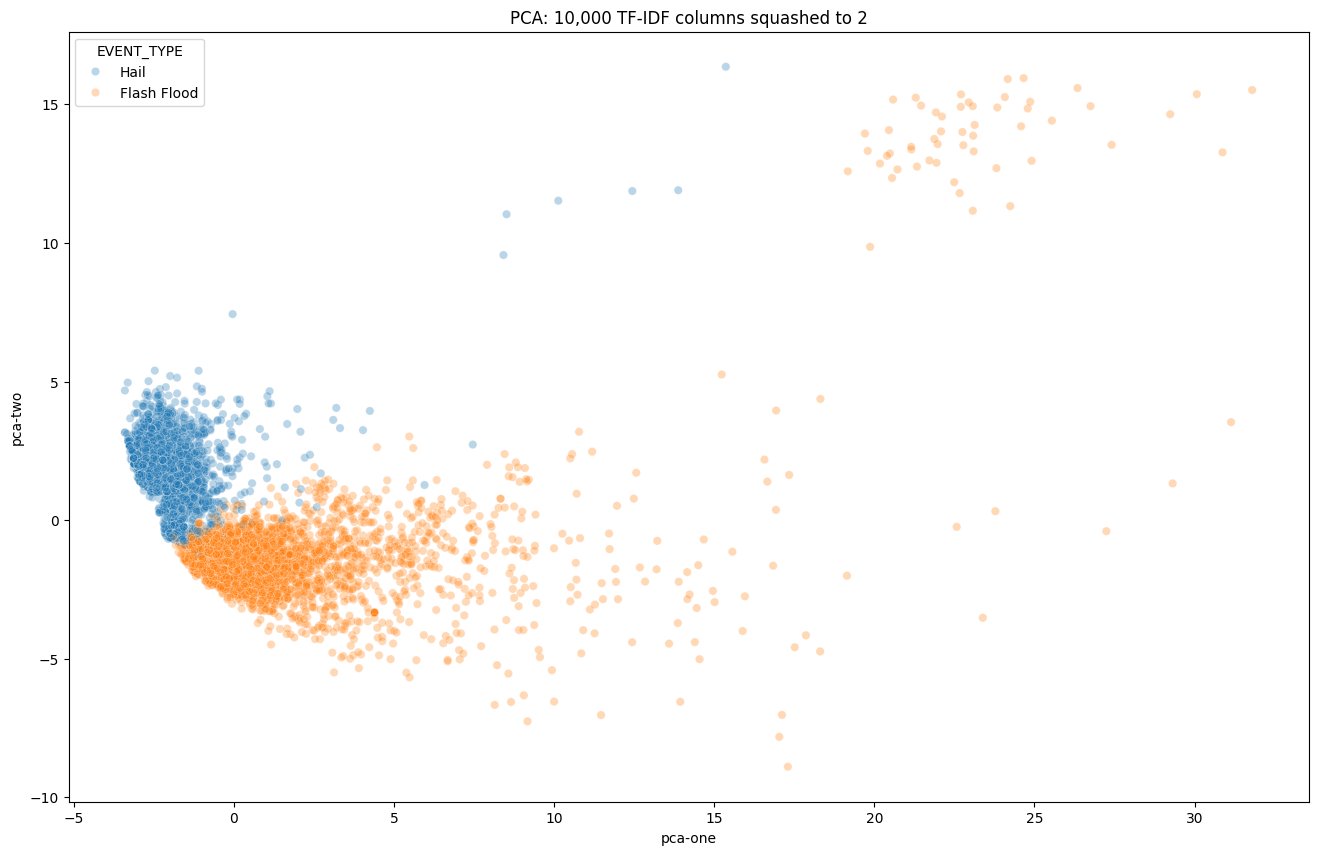

In [20]:
# one dot per narrative, colored by storm type
plt.figure(figsize=(16,10))
sns.scatterplot(data=tmp, x='pca-one', y='pca-two', hue='EVENT_TYPE', alpha=0.3)
plt.title('PCA: 10,000 TF-IDF columns squashed to 2')
plt.show()

# hail is a tight clump; flash floods spread out - mostly separate already, even with a straight-line squash

In [21]:
# t-SNE on the 50 PCA columns (t-SNE is slow on 10,000 columns, so PCA shrinks them first)
from time import time
time_start = time()
# verbose=0: t-SNE's progress log (nearest neighbors, 'KL divergence') is for debugging, not for us
tsne = TSNE(n_components=2, perplexity=40, max_iter=300, random_state=5509, verbose=0)  # scikit-learn renamed n_iter -> max_iter (n_iter is gone in 1.7+)
tsne_results = tsne.fit_transform(pca_result)
print('t-SNE done in', round(time() - time_start), 'seconds')

t-SNE done in 19 seconds


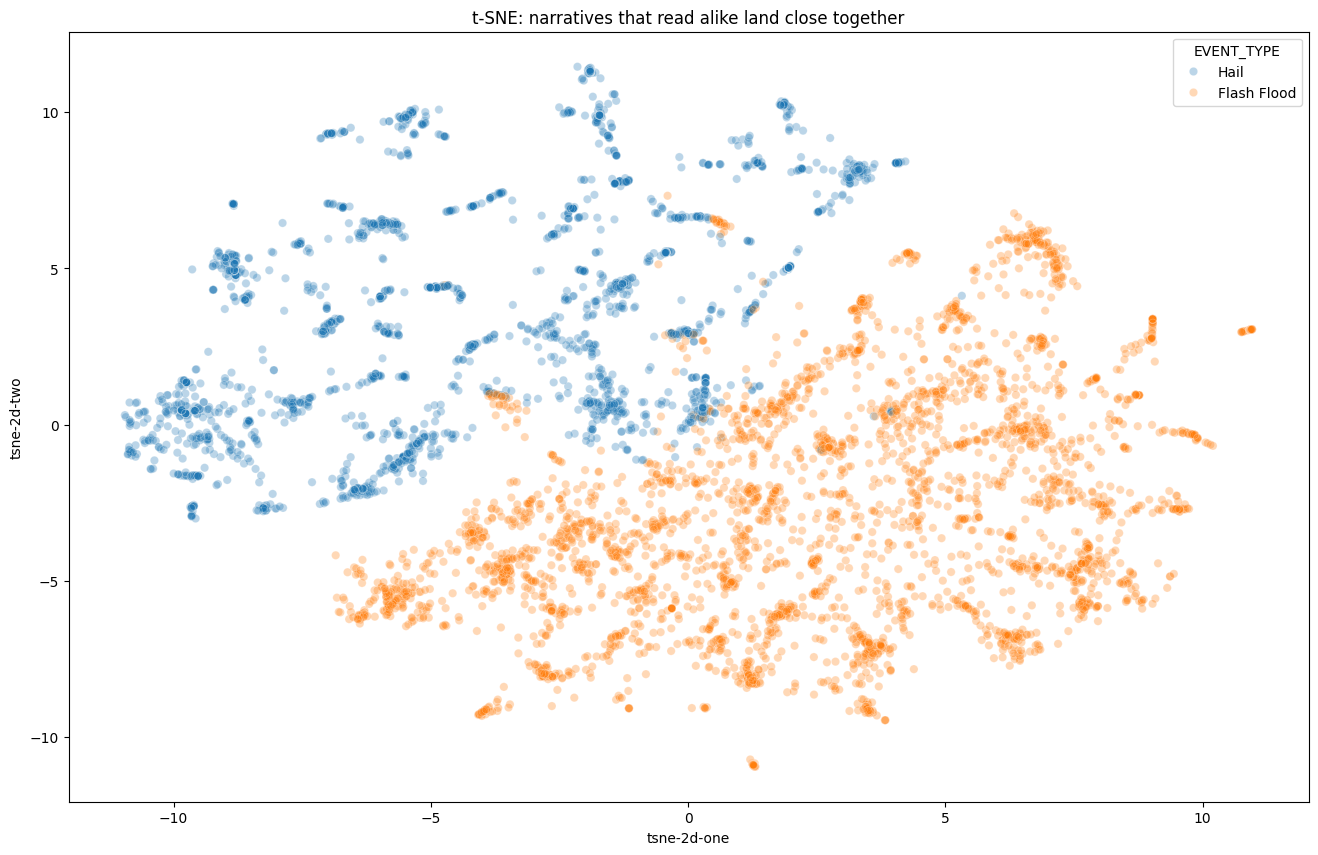

In [22]:
tmp['tsne-2d-one'] = tsne_results[:,0]
tmp['tsne-2d-two'] = tsne_results[:,1]
plt.figure(figsize=(16,10))
sns.scatterplot(data=tmp, x='tsne-2d-one', y='tsne-2d-two', hue='EVENT_TYPE', alpha=0.3)
plt.title('t-SNE: narratives that read alike land close together')
plt.show()

**The payoff:** hail and flash flood land on two separate islands - which is exactly why the models in EDA_ML_Storms scored 0.99. The storm types really do live in different places.

Now picture all 15 storm types at once: Flood and Flash Flood would sit on top of each other - and that's exactly where the network below makes most of its mistakes.

*(The 2022 version of these plots looked like random confetti because of a bug: the colors were lined up by pandas index label instead of by position, so only about 700 of the 6,606 dots were drawn and most had the wrong color.)*

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 6 — A dense network on TF-IDF: baseline, early stopping, macro F1, class weights
- A baseline to beat first: always guess Thunderstorm Wind -> accuracy 0.454, macro F1 0.042.
- Input(10,000) -> Dense 100 -> Dropout .5 -> Dense 100 -> Dropout .5 -> Dense 15 softmax. 1,011,715 parameters - 1,000,100 in the first layer (10,000 x 100 + 100).
- EarlyStopping(patience=20, restore_best_weights=True) watches validation_split=0.2 of TRAIN - the test set stays untouched. It runs 23 epochs and keeps epoch 3 (validation loss 0.237). The loss curve sits RIGHT under the fit: validation loss bottoms at 3, then climbs for 20 epochs while training loss keeps falling - textbook overfitting. (Tested: a smaller 32/32 net drops to 0.47 macro F1; learning_rate=0.0001 gives a smoother curve, same score - it's not too big.)
- Test accuracy 0.93... MACRO F1 0.67. Four rare storms score 0.00: Dust Devil (3 test cases), Marine Hail (4), Marine High Wind (10), Marine Strong Wind (9). Macro counts every class the same.
- argmax on the PROBABILITIES: the 2022 cell rounded first, and a row with no class above 0.5 rounds to all zeros -> argmax = 0 = Debris Flow.
- The heatmap with storm names: Flood vs Flash Flood is the big off-diagonal block - 176 flash floods called Flood.
- Class weights ('balanced': Dust Devil gets 451, Thunderstorm Wind 0.15): macro F1 0.67 -> 0.69, accuracy 0.925 -> 0.904. The +0.02 is almost all two classes with 9 and 10 test cases (0 -> 0.27, 0.22) - one or two lucky hits - and every big class got a bit worse (Tornado 0.97 -> 0.92). Dust Devil and Marine Hail stay 0. Class weights can't create signal that isn't there.
- Merge instead: every type with < 50 narratives -> 'Other (rare)' (Dust Devil, Marine Hail, Marine Strong Wind, Marine High Wind = 81 narratives), 15 -> 12 classes. Macro F1 0.85, accuracy 0.926 - but most of that jump is four 0.00 classes leaving the average, and 'Other' still finds only 3 of its 26 test cases (recall 0.12, precision 1.00). Merging makes the problem honest; it doesn't make rare storms easy.
- Try it (last cell): Keras' Tokenizer has NO stop-word option (filters strips punctuation, not words), so remove them BEFORE it. Result: macro F1 0.67 -> 0.66, accuracy 0.925 -> 0.920 - a hair WORSE. TF-IDF already crushes words that are everywhere, and NLTK's list includes 'down': 'knocked down trees' becomes 'knocked trees'. A textbook cleaning step isn't automatically better - test it.
-->

# A baseline to beat
Before any network: what does "always guess the biggest storm type" score?

In [23]:
# the majority-class baseline
from sklearn.metrics import accuracy_score, f1_score

biggest = y_train.sum(axis=0).argmax()
print('biggest class in train:', lb.classes_[biggest])
baseline_preds = np.full(len(y_test), biggest)
print('baseline test accuracy:', round(accuracy_score(y_test.argmax(axis=1), baseline_preds), 3))
print('baseline test macro F1:', round(f1_score(y_test.argmax(axis=1), baseline_preds, average='macro'), 3))

# accuracy looks OK... macro F1 does not. Every class counts the same in macro F1.

biggest class in train: Thunderstorm Wind
baseline test accuracy: 0.454
baseline test macro F1: 0.042


# Fit the model!

In [24]:
# look how we can be smarter about the last dense layer
n_outputs = y.shape[1]
print(n_outputs)

15


In [25]:
# check X shape
print(X_train.shape)

(20276, 10000)


In [26]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))    # one row of TF-IDF scores in
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(n_outputs, activation='softmax'))
model.summary()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │     1,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,011,715 (3.86 MB)

 Trainable params: 1,011,715 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

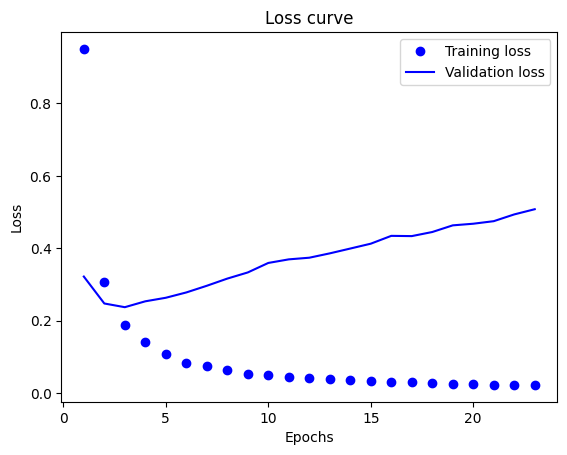

epochs run: 23 | best validation loss: 0.2372 at epoch 3


In [27]:
from keras.callbacks import EarlyStopping

# stop when validation loss stops improving - and hand back the BEST epoch's weights
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)   # wait 20 epochs for an improvement

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=100,
                    validation_split=0.2,   # 20% of TRAIN - the test set stays untouched until the very end
                    callbacks=[early_stop],
                    verbose=0)

# loss curve - always look at this after a fit!
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

best_epoch = val_loss.index(min(val_loss)) + 1
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', best_epoch)
# validation loss bottoms out early, then climbs while training loss keeps falling = OVERFITTING.
# EarlyStopping waited 20 more epochs to be sure, then restore_best_weights handed back the best epoch.
# try it: keras.optimizers.Adam(learning_rate=0.0001) in compile() - a slower, smoother curve (about the same score)

# Evaluate!

In [28]:
# classification report and confusion matrix
from sklearn.metrics import confusion_matrix

# see how the model did! one probability per storm type, per narrative
# (argmax on the PROBABILITIES - rounding first turns an unsure row into all zeros,
#  and argmax of all zeros is class 0, Debris Flow)
preds = model.predict(X_test, verbose=0)
preds[0].round(3)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
      dtype=float32)

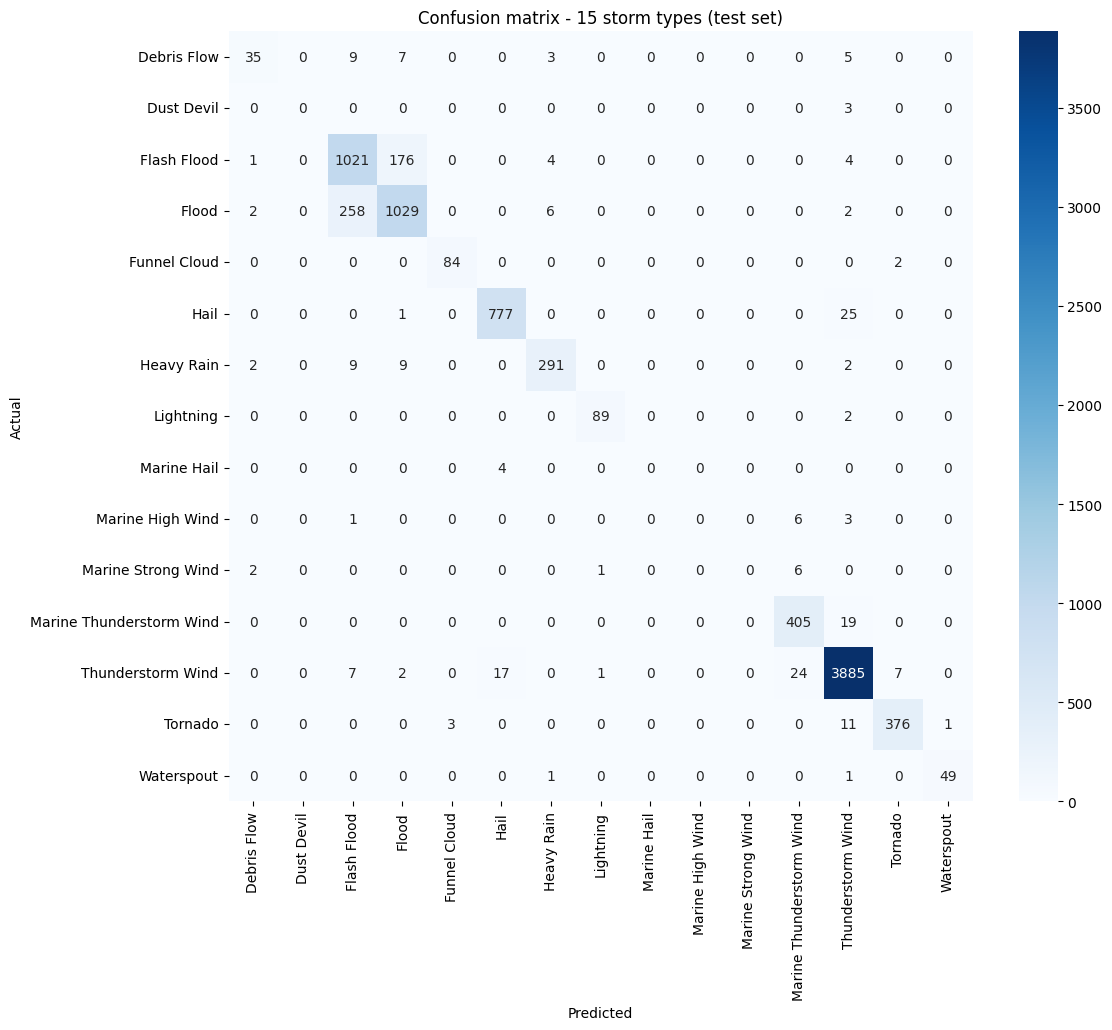

In [29]:
# confusion matrix - as a heatmap with the storm names, so you can actually read it
import seaborn as sns

matrix = confusion_matrix(y_test.argmax(axis=1), preds.argmax(axis=1))
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix - 15 storm types (test set)')
plt.show()

In [30]:
# classification report (need argmax!) - now with the storm names
from sklearn.metrics import classification_report

print(classification_report(y_test.argmax(axis=1), preds.argmax(axis=1), target_names=lb.classes_, zero_division=0))

# one number to compare models: macro F1 (every class counts the same, big or small)
from sklearn.metrics import f1_score
print('test macro F1:', round(f1_score(y_test.argmax(axis=1), preds.argmax(axis=1), average='macro'), 3))

                          precision    recall  f1-score   support

             Debris Flow       0.83      0.59      0.69        59
              Dust Devil       0.00      0.00      0.00         3
             Flash Flood       0.78      0.85      0.81      1206
                   Flood       0.84      0.79      0.82      1297
            Funnel Cloud       0.97      0.98      0.97        86
                    Hail       0.97      0.97      0.97       803
              Heavy Rain       0.95      0.93      0.94       313
               Lightning       0.98      0.98      0.98        91
             Marine Hail       0.00      0.00      0.00         4
        Marine High Wind       0.00      0.00      0.00        10
      Marine Strong Wind       0.00      0.00      0.00         9
Marine Thunderstorm Wind       0.92      0.96      0.94       424
       Thunderstorm Wind       0.98      0.99      0.98      3943
                 Tornado       0.98      0.96      0.97       391
         

In [31]:
# what were original labels?
# link: https://stackoverflow.com/questions/42196589/any-way-to-get-mappings-of-a-label-encoder-in-python-pandas
lb_name_mapping = dict(zip(lb.classes_, lb.transform(lb.classes_)))
print(lb_name_mapping)

{'Debris Flow': np.int64(0), 'Dust Devil': np.int64(1), 'Flash Flood': np.int64(2), 'Flood': np.int64(3), 'Funnel Cloud': np.int64(4), 'Hail': np.int64(5), 'Heavy Rain': np.int64(6), 'Lightning': np.int64(7), 'Marine Hail': np.int64(8), 'Marine High Wind': np.int64(9), 'Marine Strong Wind': np.int64(10), 'Marine Thunderstorm Wind': np.int64(11), 'Thunderstorm Wind': np.int64(12), 'Tornado': np.int64(13), 'Waterspout': np.int64(14)}


## Class weights: do the rare storms get a fair shake?
Thunderstorm Wind has thousands of examples and Dust Devil has a handful, so the loss is dominated by the big classes. `class_weight='balanced'` makes every mistake on a rare class cost more - here's what that buys (and costs).

* https://datascience.stackexchange.com/questions/13490/how-to-set-class-weights-for-imbalanced-classes-in-keras

In [32]:
# balanced weights: (number of rows) / (number of classes x rows in that class)
from sklearn.utils.class_weight import compute_class_weight

train_labels = y_train.argmax(axis=1)
present = np.unique(train_labels)
weights = compute_class_weight(class_weight='balanced', classes=present, y=train_labels)

class_weights = {}
for k in range(n_outputs):
    class_weights[k] = 1.0            # a class missing from train keeps weight 1
for k in range(len(present)):
    class_weights[int(present[k])] = float(weights[k])

for k in range(n_outputs):
    print(f'{lb.classes_[k]:28s} weight {class_weights[k]:8.2f}')

Debris Flow                  weight    12.40
Dust Devil                   weight   450.58
Flash Flood                  weight     0.51
Flood                        weight     0.46
Funnel Cloud                 weight     7.43
Hail                         weight     0.69
Heavy Rain                   weight     1.72
Lightning                    weight     6.47
Marine Hail                  weight   168.97
Marine High Wind             weight    36.53
Marine Strong Wind           weight   193.10
Marine Thunderstorm Wind     weight     1.21
Thunderstorm Wind            weight     0.15
Tornado                      weight     1.44
Waterspout                   weight    14.38


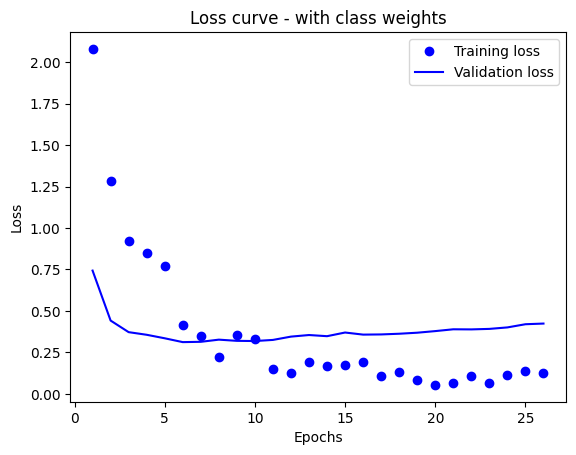

epochs run: 26 | best validation loss: 0.3124 at epoch 6


In [33]:
# same network, same seed - the ONLY change is class_weight
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model_cw = Sequential()
model_cw.add(Input(shape=(X_train.shape[1],)))
model_cw.add(Dense(100, activation='relu'))
model_cw.add(Dropout(0.5))
model_cw.add(Dense(100, activation='relu'))
model_cw.add(Dropout(0.5))
model_cw.add(Dense(n_outputs, activation='softmax'))
model_cw.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_cw = model_cw.fit(X_train, y_train,
                          epochs=50,
                          batch_size=100,
                          validation_split=0.2,
                          class_weight=class_weights,
                          callbacks=[early_stop],
                          verbose=0)

# loss curve - always look at this after a fit!
loss = history_cw.history['loss']
val_loss = history_cw.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve - with class weights')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', val_loss.index(min(val_loss)) + 1)

In [34]:
# side by side: F1 for every storm type, without and with class weights
true = y_test.argmax(axis=1)
pred_plain = preds.argmax(axis=1)
pred_cw = model_cw.predict(X_test, verbose=0).argmax(axis=1)

all_classes = list(range(n_outputs))
comparison = pd.DataFrame({'storm type': lb.classes_,
                           'test cases': np.bincount(true, minlength=n_outputs),
                           'F1 plain': f1_score(true, pred_plain, labels=all_classes, average=None, zero_division=0).round(2),
                           'F1 class weights': f1_score(true, pred_cw, labels=all_classes, average=None, zero_division=0).round(2)})
print(comparison.to_string(index=False))
print()
print('test macro F1   plain:', round(f1_score(true, pred_plain, average='macro'), 3),
      '| class weights:', round(f1_score(true, pred_cw, average='macro'), 3))
print('test accuracy   plain:', round(accuracy_score(true, pred_plain), 3),
      '| class weights:', round(accuracy_score(true, pred_cw), 3))

# the honest read: class weights bought about +0.02 macro F1 - almost all of it from two classes with 9 and 10 test cases
# (one or two lucky hits) - and every big class got a little WORSE (Tornado 0.97 -> 0.92). Dust Devil and Marine Hail stay at 0.00.
# class weights can't create signal that isn't there: 3 examples is not enough to learn from.
# better fixes: get more data, or merge the tiny classes (next).

              storm type  test cases  F1 plain  F1 class weights
             Debris Flow          59      0.69              0.69
              Dust Devil           3      0.00              0.00
             Flash Flood        1206      0.81              0.80
                   Flood        1297      0.82              0.80
            Funnel Cloud          86      0.97              0.95
                    Hail         803      0.97              0.94
              Heavy Rain         313      0.94              0.94
               Lightning          91      0.98              0.96
             Marine Hail           4      0.00              0.00
        Marine High Wind          10      0.00              0.27
      Marine Strong Wind           9      0.00              0.22
Marine Thunderstorm Wind         424      0.94              0.93
       Thunderstorm Wind        3943      0.98              0.97
                 Tornado         391      0.97              0.92
              Waterspout 

## Or: merge the tiny classes
Class weights can't create signal that isn't there - a storm type with a handful of narratives just isn't learnable. The common fix is to **merge** them: every storm type with fewer than 50 narratives becomes one class, `Other (rare)`. 15 classes become 12. Same narratives, same split, same network - only the labels change.

In [35]:
# which storm types have fewer than 50 narratives?
type_counts = df['EVENT_TYPE'].value_counts()
rare_types = list(type_counts[type_counts < 50].index)
print('merging:', rare_types)

def merge_rare(storm_type):
    """Keep the common storm types, lump the rare ones together."""
    if storm_type in rare_types:
        return 'Other (rare)'
    return storm_type

merged_types = df['EVENT_TYPE'].apply(merge_rare)
print(merged_types.value_counts())

# new labels, SAME split (same random_state), so the TF-IDF matrices X_train and X_test still line up
lb_m = LabelEncoder()
y_m = keras.utils.to_categorical(lb_m.fit_transform(merged_types))
n_outputs_m = y_m.shape[1]
X_train_text_m, X_test_text_m, y_train_m, y_test_m = train_test_split(X, y_m,
                                                                      random_state=42,
                                                                      train_size=0.7)
print('same training rows as before:', (X_train_text_m.index == X_train_text.index).all())
print(n_outputs_m, 'classes now')

merging: ['Marine High Wind', 'Marine Strong Wind', 'Marine Hail', 'Dust Devil']
EVENT_TYPE
Thunderstorm Wind           13178
Flood                        4253
Flash Flood                  3851
Hail                         2755
Marine Thunderstorm Wind     1537
Tornado                      1329
Heavy Rain                   1101
Lightning                     300
Funnel Cloud                  268
Debris Flow                   168
Waterspout                    145
Other (rare)                   81
Name: count, dtype: int64
same training rows as before: True
12 classes now


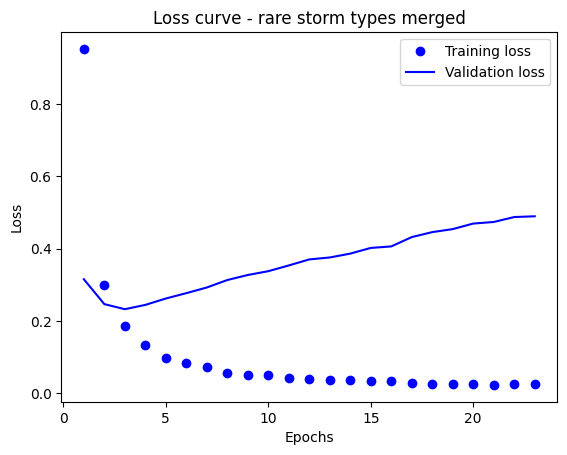

epochs run: 23 | best validation loss: 0.2327 at epoch 3


In [36]:
# same network, same seed - only the number of outputs changes (12 instead of 15)
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model_m = Sequential()
model_m.add(Input(shape=(X_train.shape[1],)))
model_m.add(Dense(100, activation='relu'))
model_m.add(Dropout(0.5))
model_m.add(Dense(100, activation='relu'))
model_m.add(Dropout(0.5))
model_m.add(Dense(n_outputs_m, activation='softmax'))
model_m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_m = model_m.fit(X_train, y_train_m,
                        epochs=50,
                        batch_size=100,
                        validation_split=0.2,
                        callbacks=[early_stop],
                        verbose=0)

# loss curve - always look at this after a fit!
loss = history_m.history['loss']
val_loss = history_m.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve - rare storm types merged')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', val_loss.index(min(val_loss)) + 1)

In [37]:
# how did it do? every storm type, including the new 'Other (rare)'
true_m = y_test_m.argmax(axis=1)
pred_m = model_m.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(true_m, pred_m, target_names=lb_m.classes_, zero_division=0))
print('test macro F1 (12 classes):', round(f1_score(true_m, pred_m, average='macro'), 3))
print('test accuracy:', round(accuracy_score(true_m, pred_m), 3))

# macro F1 jumps 0.67 -> 0.85 - but careful: most of that jump is four 0.00 classes LEAVING the average (12 classes now, not 15).
# 'Other (rare)' itself is still hard: of its 26 test narratives it finds only 3 (recall 0.12) - but when it says 'Other', it's right (precision 1.00).
# the lesson: merging makes the problem honest about what's learnable. It doesn't make rare storms easy.

                          precision    recall  f1-score   support

             Debris Flow       0.86      0.54      0.67        59
             Flash Flood       0.79      0.85      0.82      1206
                   Flood       0.84      0.80      0.82      1297
            Funnel Cloud       0.95      0.98      0.97        86
                    Hail       0.97      0.96      0.97       803
              Heavy Rain       0.95      0.95      0.95       313
               Lightning       0.99      0.96      0.97        91
Marine Thunderstorm Wind       0.92      0.96      0.94       424
            Other (rare)       1.00      0.12      0.21        26
       Thunderstorm Wind       0.98      0.99      0.98      3943
                 Tornado       0.96      0.96      0.96       391
              Waterspout       1.00      0.90      0.95        51

                accuracy                           0.93      8690
               macro avg       0.94      0.83      0.85      8690
        

## Does removing stop words help? (try it!)
Keras' `Tokenizer` has **no stop-word option** - its `filters` argument strips punctuation characters, not words. So we remove stop words ourselves, BEFORE the Tokenizer, with the same `remove_stopwords()` idea from EDA_ML_Storms. Everything else stays exactly the same: same split, same network, same seed. Only the words change.

In [38]:
# NLTK's English stop words (the same list as EDA_ML_Storms)
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop = set(stopwords.words('english'))

def remove_stopwords(text):
    """Keep every word that is NOT a stop word (checked in lowercase, ignoring punctuation stuck to it)."""
    kept = []
    for word in text.split():
        if word.lower().strip(string.punctuation) not in stop:
            kept.append(word)
    return ' '.join(kept)

X_train_ns = X_train_text.apply(remove_stopwords)
X_test_ns = X_test_text.apply(remove_stopwords)

print('before:', X_train_text.iloc[0])
print('after: ', X_train_ns.iloc[0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dww05002\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


before: A severe thunderstorm producing winds estimated near 60 mph knocked down trees in New Berlin.
after:  severe thunderstorm producing winds estimated near 60 mph knocked trees New Berlin.


unique words with stop words:    16050
unique words without stop words: 15981


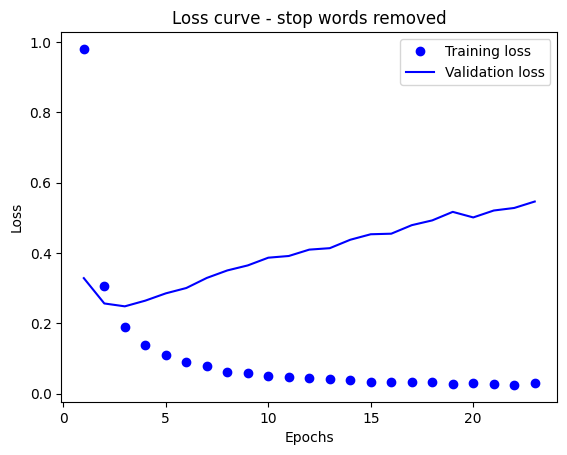

epochs run: 23 | best validation loss: 0.2481 at epoch 3


test macro F1   with stop words: 0.67 | without: 0.659
test accuracy   with stop words: 0.925 | without: 0.92


In [39]:
# same Tokenizer settings, fit on the stop-word-free TRAINING text
t_ns = Tokenizer(num_words=10000)
t_ns.fit_on_texts(X_train_ns)
X_train_nostop = t_ns.texts_to_matrix(X_train_ns, mode='tfidf')
X_test_nostop = t_ns.texts_to_matrix(X_test_ns, mode='tfidf')
print('unique words with stop words:   ', len(t.word_index))
print('unique words without stop words:', len(t_ns.word_index))

# same network, same seed
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model_ns = Sequential()
model_ns.add(Input(shape=(X_train_nostop.shape[1],)))
model_ns.add(Dense(100, activation='relu'))
model_ns.add(Dropout(0.5))
model_ns.add(Dense(100, activation='relu'))
model_ns.add(Dropout(0.5))
model_ns.add(Dense(n_outputs, activation='softmax'))
model_ns.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_ns = model_ns.fit(X_train_nostop, y_train,
                          epochs=50,
                          batch_size=100,
                          validation_split=0.2,
                          callbacks=[early_stop],
                          verbose=0)

# loss curve - always look at this after a fit!
loss = history_ns.history['loss']
val_loss = history_ns.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve - stop words removed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', val_loss.index(min(val_loss)) + 1)

pred_ns = model_ns.predict(X_test_nostop, verbose=0).argmax(axis=1)
print('test macro F1   with stop words:', round(f1_score(true, pred_plain, average='macro'), 3),
      '| without:', round(f1_score(true, pred_ns, average='macro'), 3))
print('test accuracy   with stop words:', round(accuracy_score(true, pred_plain), 3),
      '| without:', round(accuracy_score(true, pred_ns), 3))

# TF-IDF already crushes words that show up everywhere (that's the IDF part), so stop-word removal
# has little left to do - and a few 'stop words' ('in', 'of') actually carry signal here (see the SHAP notebook).
# A textbook cleaning step is not automatically better: TEST it.

It worked! If you want some more NLP customization (i.e. removing stopwords etc.), check out this article: https://machinelearningmastery.com/deep-learning-bag-of-words-model-sentiment-analysis/